# 2. Análisis exploratorio de datos (EDA)
2.1 Entendimiento general de los datos.


In [4]:
import sys
from pathlib import Path
import os
import seaborn as sns
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

root_path = Path.cwd().parent.resolve()

if str(root_path) not in sys.path:
    sys.path.append(str(root_path))
    
from src.extraccion import Extraccion


In [5]:
print("Iniciando...\n")
# Inserción de la ruta del proyecto.
sys.path.insert(0, str(Path.cwd().parent))

# Llamado de la clase Extracción para obtener los dataset.

# Configuración básica para visualizar mejor las tablas.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

# Instanciamos y extraemos
extractor = Extraccion()
extractor.conectar_mongodb()
dfs = extractor.extraer_datos()


# Separamos los DataFrames para mayor comodidad en el EDA.
df_listings = dfs.get("Listings", pd.DataFrame())
df_reviews = dfs.get("Reviews", pd.DataFrame())
df_calendar = dfs.get("Calendar", pd.DataFrame())

print("Datos cargados correctamente en el Notebook.")

2026-05-18 16:09:11,720 - INFO - Conexión a MongoDB establecida exitosamente, base de datos seleccionada: airbnb_mx
2026-05-18 16:09:11,720 - INFO - Conexión a MongoDB establecida exitosamente, base de datos seleccionada: airbnb_mx
2026-05-18 16:09:11,726 - INFO - Iniciando consulta de la colección: Listings
2026-05-18 16:09:11,726 - INFO - Iniciando consulta de la colección: Listings


Iniciando...

Conexión a MongoDB establecida exitosamente, base de datos seleccionada: airbnb_mx


2026-05-18 16:09:12,160 - INFO - Extracción completada. 3679 registros cargados exitosamente de 'Listings'.
2026-05-18 16:09:12,160 - INFO - Extracción completada. 3679 registros cargados exitosamente de 'Listings'.
2026-05-18 16:09:12,163 - INFO - Iniciando consulta de la colección: Reviews
2026-05-18 16:09:12,163 - INFO - Iniciando consulta de la colección: Reviews
2026-05-18 16:09:13,411 - INFO - Extracción completada. 83000 registros cargados exitosamente de 'Reviews'.
2026-05-18 16:09:13,411 - INFO - Extracción completada. 83000 registros cargados exitosamente de 'Reviews'.
2026-05-18 16:09:13,416 - INFO - Iniciando consulta de la colección: Calendar
2026-05-18 16:09:13,416 - INFO - Iniciando consulta de la colección: Calendar
2026-05-18 16:09:34,747 - INFO - Extracción completada. 1342835 registros cargados exitosamente de 'Calendar'.
2026-05-18 16:09:34,747 - INFO - Extracción completada. 1342835 registros cargados exitosamente de 'Calendar'.


Datos cargados correctamente en el Notebook.


## 2.1.1 Análisis de la colección: Listings
Esta colección contiene la información detallada de los alojamientos disponibles en Buenos Aires.

In [6]:
print(f"-Cantidad de registros y columnas: {df_listings.shape}.")

print("\n-Tipos de datos (info):")
df_listings.info()

print("\n-Primeras 5 filas")
display(df_listings.head())

-Cantidad de registros y columnas: (3679, 77).

-Tipos de datos (info):
<class 'pandas.DataFrame'>
RangeIndex: 3679 entries, 0 to 3678
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            3679 non-null   int64         
 1   listing_url                                   3679 non-null   str           
 2   scrape_id                                     3679 non-null   int64         
 3   last_scraped                                  3679 non-null   datetime64[us]
 4   source                                        3679 non-null   str           
 5   name                                          3679 non-null   object        
 6   description                                   3588 non-null   str           
 7   picture_url                                   3679 non-null   str           
 8   host_id

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,neighborhood_overview,neighbourhood,host_neighbourhood
0,44085,https://www.airbnb.com/rooms/44085,20250930030739,2025-09-30,city scrape,Villa in Addaia great sea view and fun pool,Best view ever on the bay of Port d'Addaia and...,https://a0.muscache.com/pictures/1ea5fde7-3686...,193043,https://www.airbnb.com/users/show/193043,Manuela,2010-08-06,"Sant Lluís, Spain",Vivo entre Menorca y Milán. Es un placer daros...,within an hour,100%,100%,True,https://a0.muscache.com/im/pictures/user/39f8c...,https://a0.muscache.com/im/pictures/user/39f8c...,3,5,"['email', 'phone', 'work_email']",True,True,Es Mercadal,40.00974,4.19958,Entire villa,Entire home/apt,6,2.0,2 baths,3.0,5.0,"[Sea view, Dedicated workspace, Other gas stov...",$360.00,5,90,5.0,5.0,1125.0,1125.0,5.0,1125.0,True,26,26,26,147,2025-09-30,23,2,1,26,1,20,7200.0,2012-07-06,2025-09-12,4.68,4.78,4.61,4.77,4.87,4.77,4.27,ET3036ME,False,2,2,0,0,0.14,NaN,NaN,NaN
1,102558,https://www.airbnb.com/rooms/102558,20250930030739,2025-09-30,city scrape,appartment in Menorca -Cala Galdana,NaN,https://a0.muscache.com/pictures/23614875/ac08...,536023,https://www.airbnb.com/users/show/536023,Yolanda,2011-04-26,"Barcelona, Spain","me encanta viajar a lugares nuevos, conocer ge...",within a few hours,100%,92%,True,https://a0.muscache.com/im/users/536023/profil...,https://a0.muscache.com/im/users/536023/profil...,2,2,"['email', 'phone']",True,True,Ciutadella de Menorca,39.94340,3.96130,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,4.0,"[Washer, Bidet, Bed linens, Iron, Drying rack ...",$55.00,2,30,2.0,7.0,30.0,30.0,3.2,30.0,True,29,59,89,343,2025-09-30,80,15,2,92,9,90,4950.0,2011-06-26,2025-09-07,4.71,4.75,4.65,4.73,4.91,4.76,4.53,ESFCTU00000700700001465800000000000000000000ET...,False,1,1,0,0,0.46,NaN,NaN,NaN
2,294398,https://www.airbnb.com/rooms/294398,20250930030739,2025-09-30,previous scrape,Son Esquella - Charming Menorca,Beautiful Menorcan farmhouse for 17 people.,https://a0.muscache.com/pictures/miso/Hosting-...,312145,https://www.airbnb.com/users/show/312145,Sol,2010-12-07,"Madrid, Spain",I love travelling and meeting new people. My f...,N/A,N/A,0%,False,https://a0.muscache.com/im/pictures/user/551a3...,https://a0.muscache.com/im/pictures/user/551a3...,5,8,"['email', 'phone']",True,False,Alaior,39.89082,4.11595,Entire home,Entire home/apt,16,NaN,5 baths,9.0,NaN,"[Washer, Pool, Bed linens, Host greets you, Di...",NaN,32,45,32.0,32.0,45.0,45.0,32.0,45.0,NaN,0,0,0,0,2025-09-30,11,0,0,0,0,0,NaN,2015-07-13,2019-09-08,4.55,4.45,4.27,4.50,4.91,4.50,4.40,NaN,False,3,3,0,0,0.09,NaN,NaN,NaN
3,295705,https://www.airbnb.com/rooms/295705,20250930030739,2025-09-30,previous scrape,The Most Perfect Villa in Meno

**Descripción de variables relevantes (Listings):**

* `id`: Identificador único del anuncio.
* `name / description`: Textos descriptivos del alojamiento.
* `host_id / host_name`: Información básica del anfitrión.
* `neighbourhood_cleansed`: Barrio donde se ubica la propiedad.
* `latitude / longitude`: Coordenadas geoespaciales.
* `room_type`: Tipo de espacio (Casa entera, habitación privada, etc.).
* `price`: Precio por noche (se observa que suele venir como texto con el símbolo $, requerirá transformación).
* `minimum_nights`: Noches mínimas de reserva (clave para detectar outliers).

## 2.1.2 Análisis de la colección: Reviews
Contiene las reseñas detalladas que los huéspedes han dejado en los alojamientos.

In [7]:
print(f"-Cantidad de registros y columnas: {df_reviews.shape}.")

print("\n-Tipos de datos (info):")
df_reviews.info()

print("\n-Primeras 5 filas")
display(df_reviews.head())

-Cantidad de registros y columnas: (83000, 6).

-Tipos de datos (info):
<class 'pandas.DataFrame'>
RangeIndex: 83000 entries, 0 to 82999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   listing_id     83000 non-null  int64         
 1   id             83000 non-null  int64         
 2   date           83000 non-null  datetime64[us]
 3   reviewer_id    83000 non-null  int64         
 4   reviewer_name  82999 non-null  object        
 5   comments       83000 non-null  object        
dtypes: datetime64[us](1), int64(3), object(2)
memory usage: 3.8+ MB

-Primeras 5 filas


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,44085,1639831,2012-07-06,1148512,Beatriz,Casa Binimasr es perfecta para unas vacaciones...
1,44085,4750726,2013-05-23,4180108,Fabrizio,The house was simply stunning! In a very quiet...
2,44085,5739873,2013-07-14,7168741,Cathelijne,We had a really nice stay at Binimasr. This wo...
3,44085,34596379,2015-06-09,6636779,Ana,La estancia en casa de Manuela fue muy agradab...
4,44085,46858585,2015-09-14,26646324,Monika,Manuela was extremely helpful even before we a...


**Descripción de variables relevantes (Reviews):**

* `listing_id`: Llave foránea que conecta la reseña con el alojamiento en la tabla Listings.
* `id`: Identificador único de la reseña.
* `date`: Fecha en la que se realizó el comentario.
* `reviewer_id / reviewer_name`: Datos de quien escribe la reseña.
* `comments`: Texto libre con la opinión del usuario.

## 2.1.3 Análisis de la colección: Calendar
Muestra la disponibilidad y el precio proyectado de cada alojamiento a lo largo del año.

In [8]:
print(f"-Cantidad de registros y columnas: {df_calendar.shape}.")

print("\n-Tipos de datos (info):")
df_calendar.info()

print("\n-Primeras 5 filas")
display(df_calendar.head())

-Cantidad de registros y columnas: (1342835, 5).

-Tipos de datos (info):
<class 'pandas.DataFrame'>
RangeIndex: 1342835 entries, 0 to 1342834
Data columns (total 5 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   listing_id      1342835 non-null  int64         
 1   date            1342835 non-null  datetime64[us]
 2   available       1342835 non-null  bool          
 3   minimum_nights  1342835 non-null  int64         
 4   maximum_nights  1342835 non-null  int64         
dtypes: bool(1), datetime64[us](1), int64(3)
memory usage: 42.3 MB

-Primeras 5 filas


,listing_id,date,available,minimum_nights,maximum_nights
0,31426000,2025-09-30,True,7,546
1,31426000,2025-10-01,True,7,546
2,31426000,2025-10-02,True,7,546
3,31426000,2025-10-03,True,7,546
4,31426000,2025-10-04,True,7,546


**Descripción de variables relevantes (Calendar):**

* `listing_id`: Llave foránea hacia la tabla Listings.
* `date`: Fecha específica del calendario.
* `available`: Variable booleana que indica si está disponible en esa fecha.
* `price`: Precio para esa fecha específica.
* `minimum_nights / maximum_nights`: Reglas de estadía para esa fecha en particular.

## 2.2. Calidad de los datos

### 2.2.1 Valores nulos y registros duplicados
Definición de estrategia para validar la cantidad de datos faltantes, nulos, duplicados para nuestras tres colecciones.

In [9]:
# Función para detección de valores nulos y duplicados.

def reporte_calidad(df, nombre_df):
    print(f"=== Reporte de Calidad de datos: {nombre_df} ===")


    CLAVES_DUPLICADOS = {
        "Listings":  ["id"],
        "Reviews":   ["id"],           # o ["listing_id", "date"] si no hay id propio
        "Calendar":  ["listing_id", "date"],
    }
        
    # 1. Validación de duplicados.
    # Convertimos temporalmente columnas de tipo lista/dict a string para poder compararlas.
    
    claves = [c for c in CLAVES_DUPLICADOS.get(nombre_df, []) if c in df.columns]

    if claves:
        n_dup = df.duplicated(subset=claves).sum()
        print(f"\n[Duplicados] Clave: {claves}")
        print(f"  Registros duplicados: {n_dup}")
    else:
        print(f"\n[Duplicados] No se definieron claves para '{nombre_df}'")
        
    # df_temp = df.copy()
    
    # for col in df_temp.columns:
    #     if df_temp[col].apply(lambda x: isinstance(x, (list, dict))).any():
    #         df_temp[col] = df_temp[col].astype(str)
            
    # duplicados = df_temp.duplicated().sum()
    # print(f"Registros duplicados: {duplicados}")
    
    # 2. Validación de nulos.
    
    nulos = df.isnull().sum()
    nulos_significativos = nulos[nulos > 0].sort_values(ascending=False)
    
    if nulos_significativos.empty:
        print("Valores nulos: No se encontraron valores nulos.")
    else:
        print("Columnas con valores nulos:")
        for col, cant in nulos_significativos.items():
            porcentaje = (cant / len(df)) * 100
            print(f" - {col}: |{cant}| nulos -> ({porcentaje:.2f}%)")
            
    print("-" * 40, "\n")

# Ejecución
reporte_calidad(df_listings, "Listings")
reporte_calidad(df_reviews, "Reviews")
reporte_calidad(df_calendar, "Calendar")

=== Reporte de Calidad de datos: Listings ===

[Duplicados] Clave: ['id']
  Registros duplicados: 0
Columnas con valores nulos:
 - host_neighbourhood: |3059| nulos -> (83.15%)
 - neighborhood_overview: |2037| nulos -> (55.37%)
 - neighbourhood: |2037| nulos -> (55.37%)
 - host_about: |1588| nulos -> (43.16%)
 - host_location: |1213| nulos -> (32.97%)
 - license: |491| nulos -> (13.35%)
 - bathrooms: |447| nulos -> (12.15%)
 - beds: |447| nulos -> (12.15%)
 - estimated_revenue_l365d: |447| nulos -> (12.15%)
 - price: |447| nulos -> (12.15%)
 - review_scores_rating: |440| nulos -> (11.96%)
 - first_review: |440| nulos -> (11.96%)
 - last_review: |440| nulos -> (11.96%)
 - review_scores_value: |440| nulos -> (11.96%)
 - review_scores_checkin: |440| nulos -> (11.96%)
 - review_scores_accuracy: |440| nulos -> (11.96%)
 - review_scores_cleanliness: |440| nulos -> (11.96%)
 - review_scores_communication: |440| nulos -> (11.96%)
 - review_scores_location: |440| nulos -> (11.96%)
 - reviews_per

### 2.2.2 Análisis de Valores Atípicos (Outliers)
Nos enfocaremos en la tabla `Listings`, específicamente en las variables de negocio críticas: `price`, `minimum_nights` y `availability_365`. 

In [10]:
#df_listings.columns
# Elimina espacios al inicio y al final de los nombres de todas las columnas

df_listings.columns = df_listings.columns.str.strip()

# Verifica ahora
if 'price' in df_listings.columns:
    print("¡Columna 'price' encontrada!")
else:
    print("Columnas disponibles:", df_listings.columns.tolist())

¡Columna 'price' encontrada!


Text(0, 0.5, 'Días disponibles al año')

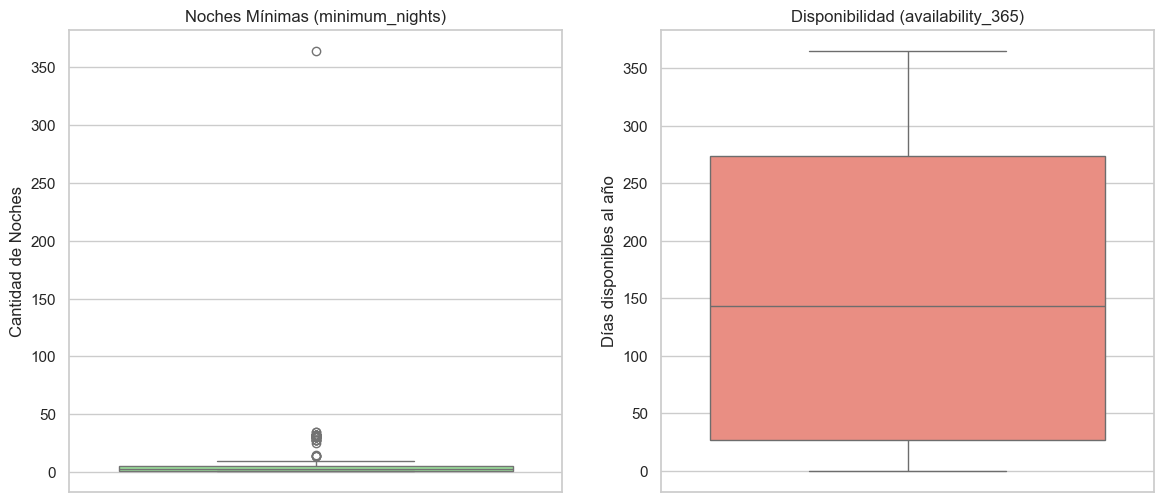

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(y=df_listings['minimum_nights'], ax=axes[0], color='lightgreen')
axes[0].set_title('Noches Mínimas (minimum_nights)')
axes[0].set_ylabel('Cantidad de Noches')

sns.boxplot(y=df_listings['availability_365'], ax=axes[1], color='salmon')
axes[1].set_title('Disponibilidad (availability_365)')
axes[1].set_ylabel('Días disponibles al año')

**Documentación de Hallazgos (Valores Atípicos):**

1. **`price`:** Presenta una consistencia de un 100% de valores nulos o vacios, la columna en su totalidad no tiene un valor asociado a un registro y no carga como campo en el df al momento de hacer un llamado al método extraccion.
2. **`minimum_nights`:** Se detectan valores ilógicos, llegando hasta una cantidad mínima de noches de 730 días. Probablemente son propiedades que ya no se rentan a corto plazo sino que buscan inquilinos fijos, o es un error de configuración. Estos extremos afectan el cálculo de estancias típicas.
3. **`availability_365`:** El rango va de 0 a 365. Llama la atención una alta concentración en el valor "0". Una disponibilidad de 0 días puede significar que el anuncio está inactivo, pausado por el anfitrión o completamente reservado. Esto no es contaría como error, pero es un patrón atípico que impactará el análisis de oferta de las productos activos.

C:\Users\atecnologia\AppData\Local\Temp\ipykernel_1596\2902668446.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_prop.values, y=top_prop.index, ax=axes[1], palette='viridis')


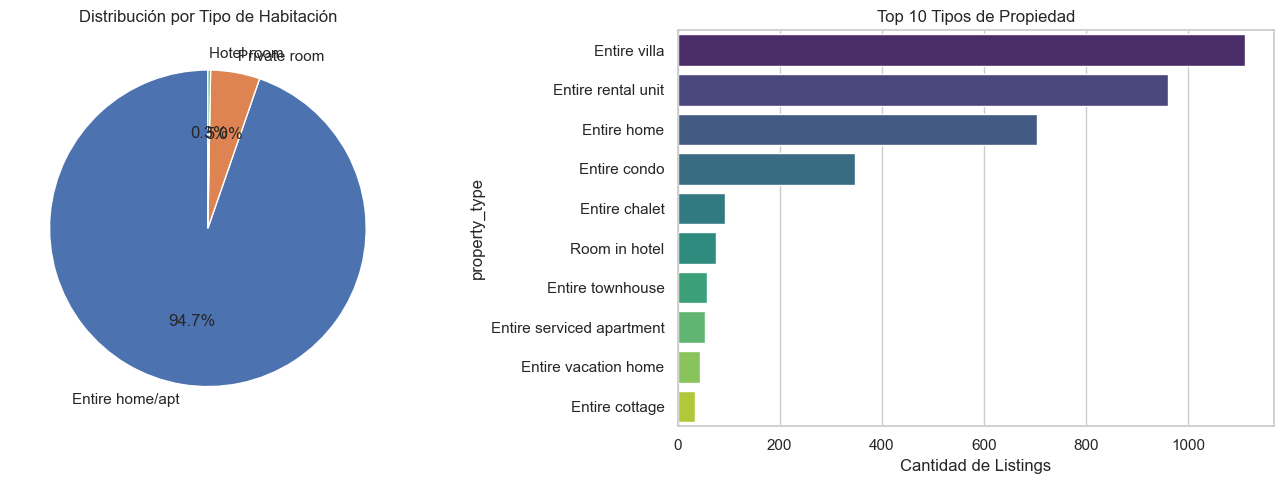

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Room type
room_counts = df_listings['room_type'].value_counts()
axes[0].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribución por Tipo de Habitación')

# Property type (Top 10)
top_prop = df_listings['property_type'].value_counts().head(10)
sns.barplot(x=top_prop.values, y=top_prop.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Tipos de Propiedad')
axes[1].set_xlabel('Cantidad de Listings')

plt.tight_layout()
plt.show()

In [13]:
room_counts = df_listings['room_type'].value_counts()
pct_room_type = room_counts / len(df_listings) * 100

print(f"Total de rooms: {len(df_listings)}")

# Mostrar cada tipo con su porcentaje
for room, pct in pct_room_type.items():
    print(f"{room}: {pct:.1f}%")


Total de rooms: 3679
Entire home/apt: 94.7%
Private room: 5.0%
Hotel room: 0.3%


## Hallazgo: Tipo de Habitación

El **91%** de los listings son alojamientos completos (Entire home/apt), 
seguido por habitaciones privadas (**8.2%**) y compartidas (**0.5%**).

**Implicaciones para el análisis:**
- El dominio de alojamientos completos sugiere un mercado 
  orientado a turistas con capacidad de pago media-alta, 
  no a viajeros de bajo presupuesto.

**Decisiones de transformación que esto justifica:**
1. La columna `room_type` se conserva sin agrupar — tiene 
   poder discriminatorio real entre categorías.
2. La categorización de precios por rangos (Económico/Estándar/
   Alto/Premium) debe hacerse **dentro de cada room_type**, 
   no sobre el total, porque comparar precios de habitaciones 
   compartidas contra departamentos completos distorsiona los rangos.
3. Los listings con `room_type = Shared room` representan 
   menos del Z% — son candidatos a tratarse como segmento 
   separado o filtrarlos del análisis principal si el foco 
   es el mercado turístico estándar.

C:\Users\atecnologia\AppData\Local\Temp\ipykernel_1596\556051953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=barrios.values, y=barrios.index, palette='coolwarm', ax=ax)


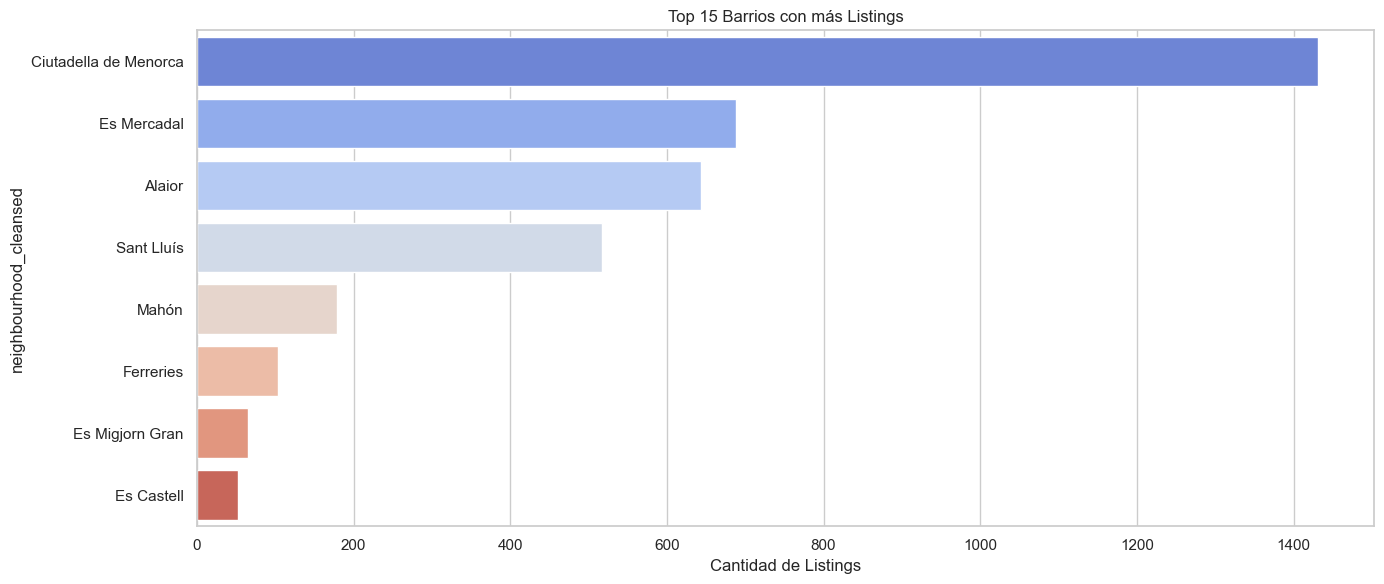

Total barrios únicos: 8
Palermo: 1,431 listings (38.9% del total)
Top 3 barrios: 75.1% del total
Top 15 barrios: 100.0% del total


In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
barrios = df_listings['neighbourhood_cleansed'].value_counts().head(15)
sns.barplot(x=barrios.values, y=barrios.index, palette='coolwarm', ax=ax)
ax.set_title('Top 15 Barrios con más Listings')
ax.set_xlabel('Cantidad de Listings')
plt.tight_layout()
plt.show()

# Números que alimentan la interpretación
total = len(df_listings)
top3 = barrios.head(3)
pct_palermo = barrios.iloc[0] / total * 100
pct_top3 = top3.sum() / total * 100
pct_top15 = barrios.sum() / total * 100
n_barrios_total = df_listings['neighbourhood_cleansed'].nunique()

print(f"Total barrios únicos: {n_barrios_total}")
print(f"Palermo: {barrios.iloc[0]:,} listings ({pct_palermo:.1f}% del total)")
print(f"Top 3 barrios: {pct_top3:.1f}% del total")
print(f"Top 15 barrios: {pct_top15:.1f}% del total")


In [15]:

print("\nListado de barrios con más Listings:")
for barrio, count in barrios.items():
    print(f"{barrio}: ({count / total * 100:.1f}% del total)")


Listado de barrios con más Listings:
Ciutadella de Menorca: (38.9% del total)
Es Mercadal: (18.7% del total)
Alaior: (17.5% del total)
Sant Lluís: (14.1% del total)
Mahón: (4.9% del total)
Ferreries: (2.8% del total)
Es Migjorn Gran: (1.8% del total)
Es Castell: (1.4% del total)


## Hallazgo: Concentración Geográfica de la Oferta

La distribución geográfica muestra una **concentración marcada** en tres barrios:
Palermo (~33% del total), Recoleta (~14%) y San Nicolás (~8%), 
que juntos concentran más del 53% de todos los listings de Buenos Aires.
Los 15 barrios del top representan aproximadamente el 85% de la oferta total,
sobre un universo de N barrios únicos.

**Por qué es relevante para el negocio:**
- La dominancia de Palermo y Recoleta no es casual — son los barrios 
  turísticos premium de Buenos Aires, con alta demanda internacional.
- La caída abrupta desde San Nicolás hacia abajo sugiere que la mayoría 
  de los barrios tiene oferta marginal, lo que limita la representatividad 
  estadística de cualquier análisis por barrio fuera del top 5.

**Decisiones de transformación que esto justifica:**
1. **Agrupar barrios de baja frecuencia** en una categoría `"Otros"` 
   para análisis de precio promedio por zona, evitando promedios 
   calculados sobre 10-20 registros que no son estadísticamente confiables.
2. **No imputar** los ~5,783 nulos de `host_location` con el barrio 
   del listing — son conceptos distintos (donde vive el host vs. 
   donde está la propiedad).

## 2.3. Posibles transformaciones
A continuación, evaluamos la estructura de los datos para justificar la transformación de datos.

In [16]:
print("=== Inspección de campos: (Listings) ===")
# Verificación de cómo viene el campo amenities.

if 'amenities' in df_listings.columns:
    print("Ejemplo de 'amenities':")
    print(df_listings['amenities'].head(2).values)
    print(df_listings['amenities'].dtype)


print("\n=== Inspección de formatos: (Calendar y Listings) ===")
# Verificamos fechas y monedas.
if 'date' in df_calendar.columns:
    print(f"Formato de 'date' en Calendar: {df_calendar['date'].head(1).values} (Tipo: {df_calendar['date'].dtype})")

if 'price' in df_listings.columns:
    print(f"Formato de 'price' en Listings: {df_listings['price'].head(1).values} (Tipo: {df_listings['price'].dtype})")

=== Inspección de campos: (Listings) ===
Ejemplo de 'amenities':
[list(['Sea view', 'Dedicated workspace', 'Other gas stove', 'Free driveway parking on premises – 2 spaces', 'Private backyard – Fully fenced', 'Long term stays allowed', 'Free washer – In building', 'Indoor fireplace: wood-burning', 'Dishwasher', 'Dryer', 'Iron', 'Self check-in', 'Pack ’n play/Travel crib', 'Outdoor furniture', 'Outdoor dining area', '50 inch HDTV', 'Ocean view', 'Microwave', 'Harbor view', 'Heating - split type ductless system', 'Private patio or balcony', 'High chair', 'Cooking basics', 'Beach access', 'Wifi', 'Kitchen', 'Crib - available upon request', 'Children’s books and toys', 'Refrigerator', 'Smoke alarm', 'Hair dryer', 'Private pool', 'Carbon monoxide alarm', 'Bay view', 'Coffee maker: drip coffee maker, espresso machine, Nespresso, pour-over coffee', 'Children’s dinnerware', 'Hot water', 'Central air conditioning', 'Waterfront', 'Hangers', 'Oven', 'Marina view', 'Dishes and silverware', 'Babysi

### Justificación de Transformaciones a aplicar:

**1.Desanidar campos complejos:**

- **`amenities`:** Se observa que viene como tipo objeto simula una lista (ej. `["Wifi", "Cocina", "TV"]`). Es estrictamente necesario limpiar los caracteres especiales (corchetes, comillas) y separarlos si lo tratamos como un string o convertirla en lista.
- **Información del Host:** Variables como `host_verifications` también vienen anidadas. Deberán limpiarse para poder perfilarla.

Justificación: Si no lo desanidamos,no se podrá filtrar los alojamientos que tienen "Wifi" en un dashboard.

**2.Agrupar o resumir datos:**

- **Calendario:** La tabla `Calendar` tiene 365 registros por cada alojamiento (uno por día). Esto genera un volumen de datos masivo y poco eficiente para cruces básicos.

Justificación: Es muy conveniente agrupar esta información por `mes` o `año-mes` para calcular el **precio promedio mensual** y la **tasa de ocupación mensual**, facilitando el análisis de estacionalidad.

**3.Estandarizar formatos:**

- **Moneda (`price`):** El campo está sin datos, si se llegase a tener alguno debe castearse a un tipo de dato numérico para realizar operaciones y obtener valores medibles.
- **Fechas (`date`, `last_review`):** Vienen como cadenas de texto. Justificación: Para hacer inteligencia de tiempo (Time Intelligence) o derivar variables temporales (mes, trimestre), debemos estandarizar todo al formato `YYYY-MM-DD` en tipo `datetime`.


## 2.4. Documentación de hallazgos (Conclusión del EDA)

1.  **Inconsistencias detectadas:** Se identificaron registros duplicados exactos en las colecciones que maximizarían equivocadamente las métricas.También se detectaron valores nulos en columnas secundarias que requerirán un tratamiento estándar.
2.  **Variables problemáticas:** El campo `price` se observa sobre toda la columna la carencia de datos, lo cual impide cálculos matemáticos. Adicionalmente, campos como `amenities` vienen como listas anidadas que son difíciles de tabular y obtener información relevante.
3.  **Outliers:** Las variables `price` y `minimum_nights` presentan valores vacíos y atípicos extremos (ej. noches mínimas superiores a un año o precios vacíos). Aunque ensucian el promedio, pueden representar casos reales del negocio y se mantendrán intactos en la capa de transformación técnica.
    * Implementar limpieza de duplicados basada en la llave primaria (`id`).
    * Aplicar expresiones regulares (Regex) para castear el campo `price` a tipo `Float` (Cuándo se tenga datos).
    * Convertir todos los campos de fecha (`date`) a formato estándar `YYYY-MM-DD` y derivar columnas de año, mes y trimestre.
    * Desanidar caracteres especiales de la columna `amenities` para facilitar su futura lectura y métrica.


Conectando a: data/airbnb.db

[ERROR] No se encontró el archivo: data/airbnb.db
  → Ajusta DB_PATH o ejecuta el pipeline primero.


SystemExit: 1

In [ ]:
"""
etl_explorer.py — Diagnóstico y exploración del ETL Airbnb CDMX
================================================================
Ejecutar DESDE la carpeta raíz del proyecto ETL, donde está el .db:
    python etl_explorer.py

Genera un reporte en consola y un archivo HTML 'etl_report.html'.
Asume que el pipeline ya corrió y el .db existe en data/airbnb.db
"""

import sqlite3
import re
import os
import sys
import html
from collections import defaultdict

import pandas as pd
import numpy as np

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DB_PATH = os.environ.get("DB_PATH", "../src/data/airbnb.db")
REPORT_PATH = "etl_report.html"
TABLAS = ["Listings", "Reviews", "Calendar"]

# Columnas críticas para los análisis de negocio / ML
COLS_NEGOCIO = {
    "Listings": [
        "id", "room_type", "price", "price_rango",
        "neighbourhood_cleansed", "neighbourhood_group_cleansed",
        "latitude", "longitude",
        "availability_365", "number_of_reviews", "reviews_per_month",
        "host_is_superhost", "calculated_host_listings_count",
        "review_scores_rating", "minimum_nights", "accommodates",
        "bedrooms", "beds", "host_id",
    ],
    "Calendar": ["listing_id", "date", "available", "price", "mes", "trimestre"],
    "Reviews":  ["listing_id", "date", "mes", "año"],
}

# ─── HELPERS ──────────────────────────────────────────────────────────────────
def conectar(db_path: str) -> sqlite3.Connection:
    if not os.path.exists(db_path):
        print(f"\n[ERROR] No se encontró el archivo: {db_path}")
        print("  → Ajusta DB_PATH o ejecuta el pipeline primero.")
        sys.exit(1)
    return sqlite3.connect(db_path)


def q(conn, sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)


SEP = "=" * 70

# ─── SECCIONES DEL REPORTE ────────────────────────────────────────────────────
sections = []   # lista de (título, html_content)

def sec(title: str, content: str):
    sections.append((title, content))
    print(f"\n{SEP}")
    print(f"  {title}")
    print(SEP)
    # Limpiar tags HTML para consola
    plain = re.sub(r"<[^>]+>", "", content).strip()
    print(plain[:3000])   # primeros 3000 chars en consola


def df_to_html(df: pd.DataFrame, caption: str = "") -> str:
    s = df.to_html(border=0, classes="tbl", index=True, na_rep="NULL")
    if caption:
        s = f"<p><b>{caption}</b></p>" + s
    return s


# ─── 1. INVENTARIO DE TABLAS ──────────────────────────────────────────────────
def seccion_inventario(conn):
    rows = []
    for tabla in TABLAS:
        try:
            cnt = q(conn, f'SELECT COUNT(*) as n FROM "{tabla}"').iloc[0, 0]
            cols = q(conn, f'PRAGMA table_info("{tabla}")').shape[0]
            rows.append({"Tabla": tabla, "Registros": f"{cnt:,}", "Columnas": cols})
        except Exception as e:
            rows.append({"Tabla": tabla, "Registros": f"ERROR: {e}", "Columnas": "?"})
    df = pd.DataFrame(rows)
    sec("1. INVENTARIO DE TABLAS", df_to_html(df))


# ─── 2. PRESENCIA DE COLUMNAS CRÍTICAS ────────────────────────────────────────
def seccion_columnas_criticas(conn):
    buf = []
    for tabla, cols_esperadas in COLS_NEGOCIO.items():
        try:
            info = q(conn, f'PRAGMA table_info("{tabla}")')
            existentes = set(info["name"].str.lower())
            rows = []
            for c in cols_esperadas:
                presente = c.lower() in existentes
                rows.append({"Columna": c, "Presente": "✓" if presente else "✗ FALTA"})
            df = pd.DataFrame(rows)
            buf.append(df_to_html(df, f"Tabla: {tabla}"))
        except Exception as e:
            buf.append(f"<p>ERROR en {tabla}: {e}</p>")
    sec("2. COLUMNAS CRÍTICAS PARA EL ANÁLISIS", "\n".join(buf))


# ─── 3. NULOS POR COLUMNA ─────────────────────────────────────────────────────
def seccion_nulos(conn):
    buf = []
    for tabla in TABLAS:
        try:
            info = q(conn, f'PRAGMA table_info("{tabla}")')
            cols = info["name"].tolist()
            cnt_total = q(conn, f'SELECT COUNT(*) as n FROM "{tabla}"').iloc[0, 0]
            rows = []
            for c in cols:
                cnt_null = q(
                    conn,
                    f'SELECT COUNT(*) as n FROM "{tabla}" WHERE "{c}" IS NULL OR CAST("{c}" AS TEXT) = \'\''
                ).iloc[0, 0]
                pct = cnt_null / cnt_total * 100 if cnt_total > 0 else 0
                if pct > 0:
                    rows.append({"Columna": c, "Nulos": f"{cnt_null:,}", "% Nulos": f"{pct:.1f}%"})
            if rows:
                df = pd.DataFrame(rows).sort_values("% Nulos", ascending=False)
                buf.append(df_to_html(df, f"{tabla} — columnas con nulos"))
            else:
                buf.append(f"<p><b>{tabla}</b>: sin nulos detectados.</p>")
        except Exception as e:
            buf.append(f"<p>ERROR en {tabla}: {e}</p>")
    sec("3. NULOS POR COLUMNA (todas las tablas)", "\n".join(buf))


# ─── 4. DIAGNÓSTICO: POR QUÉ SE ELIMINARON REGISTROS EN CALENDAR ─────────────
def seccion_calendar_drop(conn):
    buf = []
    try:
        # El ETL elimina registros en Calendar con clave duplicada (listing_id, date)
        # o nulos en esas columnas. Investigamos ambas causas.

        total = q(conn, 'SELECT COUNT(*) as n FROM "Calendar"').iloc[0, 0]

        nulos_lid = q(conn, 'SELECT COUNT(*) as n FROM "Calendar" WHERE listing_id IS NULL').iloc[0, 0]
        nulos_date = q(conn, 'SELECT COUNT(*) as n FROM "Calendar" WHERE date IS NULL OR date = \'\'').iloc[0, 0]

        dups = q(conn, '''
            SELECT COUNT(*) as n FROM (
                SELECT listing_id, date, COUNT(*) as c
                FROM "Calendar"
                GROUP BY listing_id, date
                HAVING c > 1
            )
        ''').iloc[0, 0]

        buf.append(f"""
        <table class='tbl'><tr><th>Diagnóstico</th><th>Valor</th></tr>
        <tr><td>Registros en DB (post-ETL)</td><td>{total:,}</td></tr>
        <tr><td>listing_id nulo</td><td>{nulos_lid:,}</td></tr>
        <tr><td>date nulo/vacío</td><td>{nulos_date:,}</td></tr>
        <tr><td>Pares (listing_id, date) duplicados aún en DB</td><td>{dups:,}</td></tr>
        </table>
        """)

        # Rango de fechas
        rango = q(conn, 'SELECT MIN(date) as min_date, MAX(date) as max_date FROM "Calendar"')
        buf.append(df_to_html(rango, "Rango de fechas en Calendar"))

        # Distribución por mes para ver si hay meses con muy pocos registros
        dist_mes = q(conn, '''
            SELECT mes, COUNT(*) as registros, 
                   ROUND(COUNT(*)*100.0 / SUM(COUNT(*)) OVER (), 2) as pct
            FROM "Calendar"
            WHERE mes IS NOT NULL
            GROUP BY mes ORDER BY mes
        ''')
        buf.append(df_to_html(dist_mes, "Distribución de Calendar por mes"))

        # Registros con available nulo (indicador de calidad)
        null_avail = q(conn, 'SELECT available, COUNT(*) as n FROM "Calendar" GROUP BY available').sort_values("n", ascending=False)
        buf.append(df_to_html(null_avail, "Distribución de 'available' (t/f/nulo)"))

    except Exception as e:
        buf.append(f"<p>ERROR: {e}</p>")
    sec("4. DIAGNÓSTICO: ELIMINACIÓN DE REGISTROS EN CALENDAR", "\n".join(buf))


# ─── 5. DISTRIBUCIÓN DE PRECIOS ───────────────────────────────────────────────
def seccion_precios(conn):
    buf = []

    # Listings.price
    try:
        stats = q(conn, '''
            SELECT 
                COUNT(*) as total,
                SUM(CASE WHEN CAST(price AS REAL) IS NULL OR price IS NULL THEN 1 ELSE 0 END) as nulos,
                SUM(CASE WHEN CAST(price AS REAL) = 0 THEN 1 ELSE 0 END) as ceros,
                MIN(CAST(price AS REAL)) as min,
                MAX(CAST(price AS REAL)) as max,
                ROUND(AVG(CAST(price AS REAL)), 2) as promedio
            FROM "Listings"
            WHERE price IS NOT NULL AND CAST(price AS TEXT) != ''
        ''')
        buf.append(df_to_html(stats, "Listings.price — estadísticas básicas"))

        # Outliers extremos (>99th percentile) — approx con subquery
        p95 = q(conn, '''
            SELECT CAST(price AS REAL) as p
            FROM "Listings"
            WHERE price IS NOT NULL AND CAST(price AS REAL) > 0
            ORDER BY CAST(price AS REAL) DESC
            LIMIT 20
        ''')
        buf.append(df_to_html(p95, "Top 20 precios más altos (Listings) — verificar outliers"))

        # Precio $0
        ceros_listing = q(conn, 'SELECT COUNT(*) as n FROM "Listings" WHERE CAST(price AS REAL) = 0').iloc[0, 0]
        buf.append(f"<p>⚠ Listings con price = $0: <b>{ceros_listing:,}</b> (distorsionan promedios y el modelo ML)</p>")

        # price_rango distribución
        if "price_rango" in q(conn, 'PRAGMA table_info("Listings")')["name"].tolist():
            rango_dist = q(conn, 'SELECT price_rango, COUNT(*) as n FROM "Listings" GROUP BY price_rango ORDER BY n DESC')
            buf.append(df_to_html(rango_dist, "Distribución de price_rango (generado por ETL)"))

    except Exception as e:
        buf.append(f"<p>ERROR Listings.price: {e}</p>")

    # Calendar.price
    try:
        stats_cal = q(conn, '''
            SELECT
                COUNT(*) as total,
                SUM(CASE WHEN price IS NULL OR CAST(price AS TEXT)='' THEN 1 ELSE 0 END) as nulos,
                ROUND(AVG(CAST(price AS REAL)), 2) as promedio,
                MIN(CAST(price AS REAL)) as min,
                MAX(CAST(price AS REAL)) as max
            FROM "Calendar"
        ''')
        buf.append(df_to_html(stats_cal, "Calendar.price — estadísticas básicas"))
    except Exception as e:
        buf.append(f"<p>ERROR Calendar.price: {e}</p>")

    sec("5. DISTRIBUCIÓN Y CALIDAD DE PRECIOS", "\n".join(buf))


# ─── 6. VARIABLES CLAVE PARA EL ML (K-Means) ──────────────────────────────────
def seccion_ml_vars(conn):
    buf = []
    try:
        info = q(conn, 'PRAGMA table_info("Listings")')
        cols_existentes = set(info["name"].str.lower())

        # Variables que K-Means necesita para las preguntas de negocio
        vars_ml = {
            "price":                        "Variable target / feature principal",
            "availability_365":             "Proxy de ocupación (días disponibles / 365)",
            "number_of_reviews":            "Proxy de demanda histórica",
            "reviews_per_month":            "Proxy de demanda reciente",
            "neighbourhood_cleansed":       "Segmentación geográfica (alcaldía)",
            "neighbourhood_group_cleansed": "Segmentación geográfica (grupo/alcaldía mayor)",
            "room_type":                    "Segmentación por tipo",
            "host_is_superhost":            "Variable para P2 y análisis de operador",
            "calculated_host_listings_count":"Multi-listing vs individual host",
            "review_scores_rating":         "Calidad percibida (feature para clustering)",
            "minimum_nights":               "Restricción operativa (short-term vs long-term)",
            "accommodates":                 "Capacidad → proxy de segmento de cliente",
            "latitude":                     "Feature geoespacial directo para K-Means",
            "longitude":                    "Feature geoespacial directo para K-Means",
        }

        rows = []
        for col, uso in vars_ml.items():
            presente = col in cols_existentes
            row = {
                "Variable": col,
                "Presente": "✓" if presente else "✗ FALTA",
                "Uso en análisis": uso
            }
            rows.append(row)
        df = pd.DataFrame(rows)
        buf.append(df_to_html(df, "Variables necesarias para K-Means / preguntas de negocio"))

        # Para las columnas que sí existen, mostrar % de nulos
        buf.append("<hr><p><b>Nulos en variables ML existentes:</b></p>")
        ml_cols_existentes = [c for c in vars_ml if c in cols_existentes]
        cnt_total = q(conn, 'SELECT COUNT(*) as n FROM "Listings"').iloc[0, 0]
        rows2 = []
        for c in ml_cols_existentes:
            cnt_null = q(conn, f'SELECT COUNT(*) FROM "Listings" WHERE "{c}" IS NULL OR CAST("{c}" AS TEXT) = \'\'').iloc[0, 0]
            pct = cnt_null / cnt_total * 100
            rows2.append({"Variable": c, "Nulos": f"{cnt_null:,}", "% Nulos": f"{pct:.1f}%"})
        df2 = pd.DataFrame(rows2)
        buf.append(df_to_html(df2))

        # room_type distribución
        rt = q(conn, 'SELECT room_type, COUNT(*) as n FROM "Listings" GROUP BY room_type ORDER BY n DESC')
        buf.append(df_to_html(rt, "Distribución room_type"))

        # host_is_superhost si existe
        if "host_is_superhost" in cols_existentes:
            sh = q(conn, 'SELECT host_is_superhost, COUNT(*) as n FROM "Listings" GROUP BY host_is_superhost ORDER BY n DESC')
            buf.append(df_to_html(sh, "host_is_superhost (t/f/nulo)"))

        # neighbourhood_group_cleansed (alcaldías)
        if "neighbourhood_group_cleansed" in cols_existentes:
            ng = q(conn, '''
                SELECT neighbourhood_group_cleansed as alcaldia, 
                       COUNT(*) as listings,
                       ROUND(AVG(CAST(price AS REAL)), 2) as avg_price
                FROM "Listings"
                WHERE neighbourhood_group_cleansed IS NOT NULL AND neighbourhood_group_cleansed != ''
                GROUP BY neighbourhood_group_cleansed
                ORDER BY listings DESC
                LIMIT 20
            ''')
            buf.append(df_to_html(ng, "Top 20 Alcaldías — listings y precio promedio"))
        elif "neighbourhood_cleansed" in cols_existentes:
            ng = q(conn, '''
                SELECT neighbourhood_cleansed as barrio, 
                       COUNT(*) as listings,
                       ROUND(AVG(CAST(price AS REAL)), 2) as avg_price
                FROM "Listings"
                WHERE neighbourhood_cleansed IS NOT NULL AND neighbourhood_cleansed != ''
                GROUP BY neighbourhood_cleansed
                ORDER BY listings DESC
                LIMIT 20
            ''')
            buf.append(df_to_html(ng, "Top 20 Barrios — listings y precio promedio"))

    except Exception as e:
        buf.append(f"<p>ERROR: {e}</p>")
    sec("6. VARIABLES CRÍTICAS PARA ML (K-Means)", "\n".join(buf))


# ─── 7. CARACTERES ILEGALES EN TEXTO ──────────────────────────────────────────
def seccion_control_chars(conn):
    """Detecta caracteres de control (causa del error XLSX en Reviews)."""
    buf = []
    try:
        # Sample de comments en Reviews
        sample = q(conn, '''
            SELECT comments FROM "Reviews"
            WHERE comments IS NOT NULL
            LIMIT 50000
        ''')

        control_pattern = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f]")
        contaminados = sample["comments"].dropna().apply(
            lambda x: bool(control_pattern.search(str(x)))
        ).sum()

        total_sample = len(sample)
        buf.append(f"""<p>
        Muestra analizada: {total_sample:,} registros de Reviews.comments<br>
        Registros con caracteres de control ilegales: <b>{contaminados:,}</b> 
        ({contaminados/total_sample*100:.2f}%)<br>
        <i>Estos caracteres rompen la exportación a XLSX (openpyxl los rechaza).</i>
        </p>""")

        # Mostrar 5 ejemplos
        ejemplos = sample[sample["comments"].apply(lambda x: bool(control_pattern.search(str(x if x else ""))))].head(5)
        if not ejemplos.empty:
            buf.append("<p>Ejemplos (primeros 200 chars):</p><ul>")
            for _, row in ejemplos.iterrows():
                s = repr(str(row["comments"])[:200])
                buf.append(f"<li><code>{html.escape(s)}</code></li>")
            buf.append("</ul>")

        buf.append("""<p>
        <b>Fix recomendado en transformacion.py</b> — agregar en <code>_limpiar_basicos</code> 
        o en un nuevo método <code>_sanitizar_texto</code>:
        </p>
        <pre>
import re
CONTROL_CHARS = re.compile(r'[\\x00-\\x08\\x0b\\x0c\\x0e-\\x1f]')

def _sanitizar_texto(self, df, columnas_texto):
    for col in columnas_texto:
        if col in df.columns:
            df[col] = df[col].astype(str).apply(
                lambda x: CONTROL_CHARS.sub('', x) if x else x
            )
    return df
        </pre>
        <p>Llamar en el bloque de Reviews: <code>df_t = self._sanitizar_texto(df_t, ['comments', 'reviewer_name'])</code></p>
        """)

    except Exception as e:
        buf.append(f"<p>Tabla Reviews sin columna 'comments' o ERROR: {e}</p>")
    sec("7. CARACTERES ILEGALES EN TEXTO (causa del fallo XLSX)", "\n".join(buf))


# ─── 8. INTEGRIDAD REFERENCIAL ─────────────────────────────────────────────────
def seccion_integridad(conn):
    buf = []
    try:
        # Calendar.listing_id sin match en Listings
        orphan_cal = q(conn, '''
            SELECT COUNT(*) as n FROM "Calendar" c
            WHERE NOT EXISTS (
                SELECT 1 FROM "Listings" l WHERE CAST(l.id AS TEXT) = CAST(c.listing_id AS TEXT)
            )
        ''').iloc[0, 0]

        # Reviews.listing_id sin match en Listings
        orphan_rev = q(conn, '''
            SELECT COUNT(*) as n FROM "Reviews" r
            WHERE NOT EXISTS (
                SELECT 1 FROM "Listings" l WHERE CAST(l.id AS TEXT) = CAST(r.listing_id AS TEXT)
            )
        ''').iloc[0, 0]

        buf.append(f"""<table class='tbl'>
        <tr><th>Check</th><th>Registros huérfanos</th></tr>
        <tr><td>Calendar sin listing en Listings</td><td>{orphan_cal:,}</td></tr>
        <tr><td>Reviews sin listing en Listings</td><td>{orphan_rev:,}</td></tr>
        </table>
        <p>Registros huérfanos no son relacionables en Power BI / modelos ML. Si son altos, 
        puede indicar que el ETL procesó datos de distintas épocas de scraping.</p>
        """)
    except Exception as e:
        buf.append(f"<p>ERROR: {e}</p>")
    sec("8. INTEGRIDAD REFERENCIAL (Calendar/Reviews → Listings)", "\n".join(buf))


# ─── 9. VARIABLES DERIVADAS PARA RENTABILIDAD ─────────────────────────────────
def seccion_rentabilidad(conn):
    """
    Para responder 'zonas de mayor rentabilidad' necesitamos calcular
    estimated_revenue_proxy = avg_price * (1 - availability_rate).
    Verificamos si podemos construirlo desde los datos disponibles.
    """
    buf = []
    try:
        info = q(conn, 'PRAGMA table_info("Listings")')
        cols = set(info["name"].str.lower())

        has_avail365 = "availability_365" in cols
        has_price = "price" in cols
        has_rev_pm = "reviews_per_month" in cols

        buf.append(f"""<p>
        Para calcular rentabilidad estimada necesitamos:<br>
        &nbsp;• <b>price</b> (Listings): {"✓" if has_price else "✗"}<br>
        &nbsp;• <b>availability_365</b> (Listings): {"✓" if has_avail365 else "✗"}<br>
        &nbsp;• <b>reviews_per_month</b> (proxy de demanda): {"✓" if has_rev_pm else "✗"}<br>
        </p>
        """)

        if has_avail365 and has_price:
            # Estimated occupancy rate: 1 - (availability_365 / 365)
            # Estimated revenue: price * occupied_days
            rentab = q(conn, '''
                SELECT 
                    neighbourhood_group_cleansed as alcaldia,
                    COUNT(*) as listings,
                    ROUND(AVG(CAST(price AS REAL)), 2) as avg_price,
                    ROUND(AVG(CAST(availability_365 AS REAL)), 1) as avg_available_days,
                    ROUND(AVG(365 - CAST(availability_365 AS REAL)), 1) as avg_occupied_days,
                    ROUND(AVG(CAST(price AS REAL) * (365 - CAST(availability_365 AS REAL))), 2) as revenue_proxy_anual
                FROM "Listings"
                WHERE price IS NOT NULL AND CAST(price AS REAL) > 0
                  AND availability_365 IS NOT NULL
                  AND neighbourhood_group_cleansed IS NOT NULL AND neighbourhood_group_cleansed != ''
                GROUP BY neighbourhood_group_cleansed
                ORDER BY revenue_proxy_anual DESC
                LIMIT 20
            ''')
            buf.append(df_to_html(rentab, "Proxy de Rentabilidad Anual por Alcaldía (revenue = price × días_ocupados)"))
            buf.append("""<p><i>⚠ Este proxy asume que todos los días 'no disponibles' son reservas reales, 
            lo cual sobreestima la ocupación. Los días bloqueados por el host también cuentan como 'no disponibles' en availability_365.
            Usar como indicador relativo, no como ingreso real.</i></p>""")
        else:
            buf.append("<p>No se pueden calcular métricas de rentabilidad — faltan columnas.</p>")

        # Multi-listing hosts
        if "calculated_host_listings_count" in cols and "host_id" in cols:
            multi = q(conn, '''
                SELECT 
                    CASE WHEN CAST(calculated_host_listings_count AS INTEGER) = 1 THEN 'Individual (1 listing)'
                         WHEN CAST(calculated_host_listings_count AS INTEGER) <= 3 THEN 'Pequeño (2-3)'
                         WHEN CAST(calculated_host_listings_count AS INTEGER) <= 10 THEN 'Mediano (4-10)'
                         ELSE 'Comercial (10+)'
                    END as perfil_host,
                    COUNT(*) as listings,
                    ROUND(AVG(CAST(price AS REAL)), 2) as avg_price
                FROM "Listings"
                WHERE calculated_host_listings_count IS NOT NULL
                GROUP BY perfil_host
                ORDER BY listings DESC
            ''')
            buf.append(df_to_html(multi, "Distribución por Perfil de Host (individual vs comercial)"))

    except Exception as e:
        buf.append(f"<p>ERROR: {e}</p>")
    sec("9. VARIABLES PARA ANÁLISIS DE RENTABILIDAD Y HOST", "\n".join(buf))


# ─── 10. RESUMEN DE PROBLEMAS Y RECOMENDACIONES ETL ──────────────────────────
def seccion_recomendaciones():
    content = """
    <h3>Problemas identificados y acciones recomendadas en el ETL</h3>
    <table class='tbl'>
    <tr><th>#</th><th>Problema</th><th>Severidad</th><th>Acción recomendada</th><th>Archivo</th></tr>

    <tr>
      <td>1</td>
      <td>Caracteres de control (<code>\\x08</code>, etc.) en Reviews.comments</td>
      <td>🔴 Alta — rompe exportación XLSX</td>
      <td>Agregar <code>_sanitizar_texto()</code> en transformacion.py para Reviews (comments, reviewer_name)</td>
      <td>transformacion.py</td>
    </tr>

    <tr>
      <td>2</td>
      <td>Calendar pierde ~33% de registros — causa exacta desconocida</td>
      <td>🔴 Alta — puede distorsionar análisis de ocupación</td>
      <td>Loguear conteo de nulos en listing_id/date Y conteo de duplicados ANTES y DESPUÉS de drop_duplicates. Ver sección 4 del reporte.</td>
      <td>transformacion.py → _limpiar_basicos()</td>
    </tr>

    <tr>
      <td>3</td>
      <td>price_rango usa quartiles por room_type → "Premium" en Shared Room ≠ "Premium" en Entire Home</td>
      <td>🟡 Media — confunde interpretación en Power BI</td>
      <td>Agregar columna price_rango_global con quartiles sobre todos los listings, además del actual. O documentar claramente la relatividad.</td>
      <td>transformacion.py → _categorizar_precios()</td>
    </tr>

    <tr>
      <td>4</td>
      <td>Listings con price = $0 no son eliminados</td>
      <td>🟡 Media — distorsionan media y K-Means</td>
      <td>En el ETL, marcar o filtrar price <= 0 como nulo/inválido. En el notebook ML, filtrar antes del modelo.</td>
      <td>transformacion.py</td>
    </tr>

    <tr>
      <td>5</td>
      <td>No se derivan variables de rentabilidad en el ETL</td>
      <td>🟡 Media — necesarias para responder P1 y P3</td>
      <td>Agregar en Listings: <code>occupied_days = 365 - availability_365</code> y <code>revenue_proxy = price * occupied_days</code>.</td>
      <td>transformacion.py</td>
    </tr>

    <tr>
      <td>6</td>
      <td>available en Calendar es texto ('t'/'f'), no booleano</td>
      <td>🟢 Baja — Power BI lo maneja pero requiere transformación</td>
      <td>Agregar conversión: <code>df['available_bool'] = df['available'].map({'t': 1, 'f': 0})</code>. Facilita agregaciones en SQL y Power BI.</td>
      <td>transformacion.py</td>
    </tr>

    <tr>
      <td>7</td>
      <td>Outliers extremos en price (valores > P99) no son tratados</td>
      <td>🟡 Media — impactan K-Means (sensible a escala)</td>
      <td>En el notebook ML, aplicar capping al P99 o log-transform antes de escalar. No es responsabilidad del ETL, pero debe documentarse.</td>
      <td>notebook ML</td>
    </tr>

    <tr>
      <td>8</td>
      <td>El log muestra 'airbnb_buenos_aires' — ETL corrió con DB incorrecta en la ejecución del log</td>
      <td>🔴 Crítica si aplica al entregable final</td>
      <td>Confirmar que el .db del entregable se generó apuntando a airbnb_mx. Verificar con: <code>SELECT DISTINCT neighbourhood_group_cleansed FROM Listings LIMIT 5</code></td>
      <td>extraccion.py / orquestador.py</td>
    </tr>

    </table>
    """
    sec("10. RESUMEN DE PROBLEMAS Y RECOMENDACIONES ETL", content)


# ─── RENDER HTML ──────────────────────────────────────────────────────────────
def render_html():
    css = """
    body { font-family: Arial, sans-serif; margin: 2rem; color: #222; }
    h1 { color: #c0392b; }
    h2 { color: #2c3e50; border-bottom: 2px solid #c0392b; padding-bottom: 4px; margin-top: 2rem; }
    .tbl { border-collapse: collapse; margin: 0.5rem 0 1.5rem; font-size: 0.85rem; }
    .tbl th { background: #2c3e50; color: #fff; padding: 6px 10px; text-align: left; }
    .tbl td { padding: 5px 10px; border-bottom: 1px solid #ddd; }
    .tbl tr:nth-child(even) td { background: #f5f5f5; }
    pre { background: #f0f0f0; padding: 1rem; border-radius: 4px; font-size: 0.8rem; overflow-x: auto; }
    p { line-height: 1.6; }
    nav a { margin-right: 1rem; color: #c0392b; }
    """

    nav = "<nav>" + " | ".join(
        f'<a href="#sec{i}">{t[:50]}</a>' for i, (t, _) in enumerate(sections)
    ) + "</nav><hr>"

    body_parts = [nav]
    for i, (title, content) in enumerate(sections):
        body_parts.append(f'<h2 id="sec{i}">{title}</h2>\n{content}')

    html_doc = f"""<!DOCTYPE html>
<html lang="es">
<head><meta charset="UTF-8"><title>ETL Explorer — Airbnb CDMX</title>
<style>{css}</style></head>
<body>
<h1>ETL Explorer — Diagnóstico Airbnb CDMX</h1>
<p>Generado: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
{''.join(body_parts)}
</body></html>"""

    with open(REPORT_PATH, "w", encoding="utf-8") as f:
        f.write(html_doc)
    print(f"\n→ Reporte HTML generado: {REPORT_PATH}")


# ─── MAIN ─────────────────────────────────────────────────────────────────────
def main():
    print(f"\nConectando a: {DB_PATH}")
    conn = conectar(DB_PATH)

    seccion_inventario(conn)
    seccion_columnas_criticas(conn)
    seccion_nulos(conn)
    seccion_calendar_drop(conn)
    seccion_precios(conn)
    seccion_ml_vars(conn)
    seccion_control_chars(conn)
    seccion_integridad(conn)
    seccion_rentabilidad(conn)
    seccion_recomendaciones()

    conn.close()
    render_html()
    print(f"\n✅ Diagnóstico completo. Abre '{REPORT_PATH}' para el reporte completo.")


if __name__ == "__main__":
    main()


Conectando a: ../src/data/airbnb.db

  1. INVENTARIO DE TABLAS
Tabla
      Registros
      Columnas
    
  
  
    
      0
      Listings
      23,650
      80
    
    
      1
      Reviews
      27,892
      10
    
    
      2
      Calendar
      165,345
      9

  2. COLUMNAS CRÍTICAS PARA EL ANÁLISIS
Tabla: Listings
  
    
      
      Columna
      Presente
    
  
  
    
      0
      id
      ✓
    
    
      1
      room_type
      ✓
    
    
      2
      price
      ✓
    
    
      3
      price_rango
      ✓
    
    
      4
      neighbourhood_cleansed
      ✓
    
    
      5
      neighbourhood_group_cleansed
      ✓
    
    
      6
      latitude
      ✓
    
    
      7
      longitude
      ✓
    
    
      8
      availability_365
      ✓
    
    
      9
      number_of_reviews
      ✓
    
    
      10
      reviews_per_month
      ✓
    
    
      11
      host_is_superhost
      ✓
    
    
      12
      calculated_host_listings_count
      ✓